Dataset shape after cleaning: (1257, 25)


FEATURE ENGINEERING
✓ Created mental_health_risk score (0-6): mean=2.50
✓ Created company_support score (0-4): mean=1.05

✓ Label encoding complete
Dataset shape after encoding: (1257, 26)

Numerical features: 3
Categorical features: 23


1. K-MEANS CLUSTERING
After One-Hot Encoding: 52 features

Evaluating optimal number of clusters...


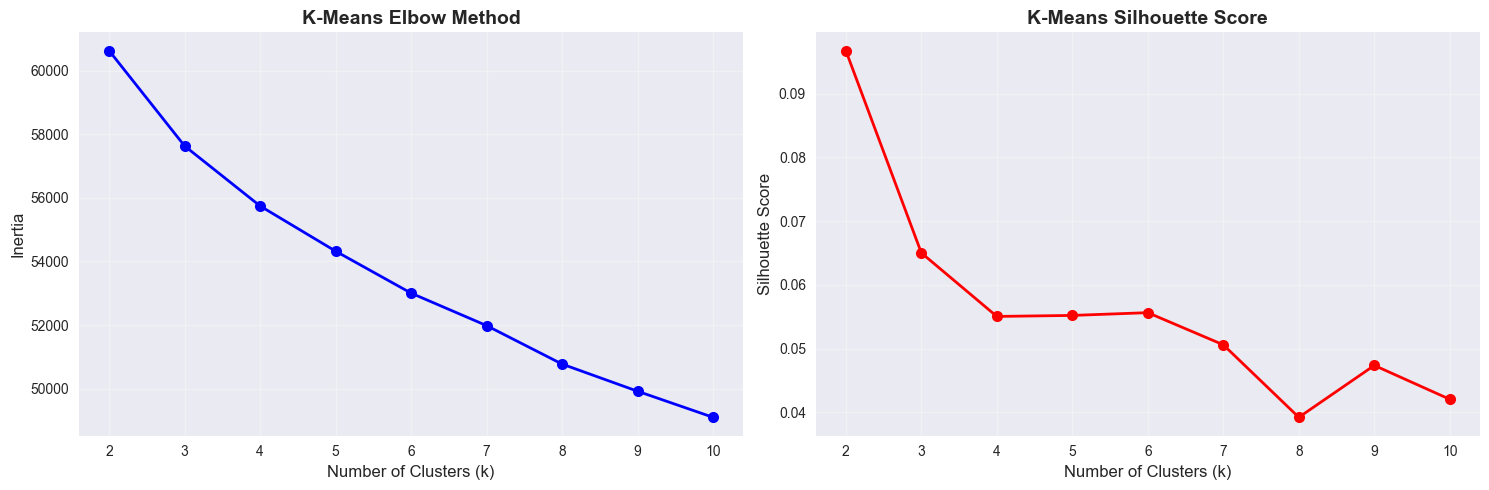


FINAL K-MEANS MODEL: 4 Clusters
Silhouette Score: 0.0550


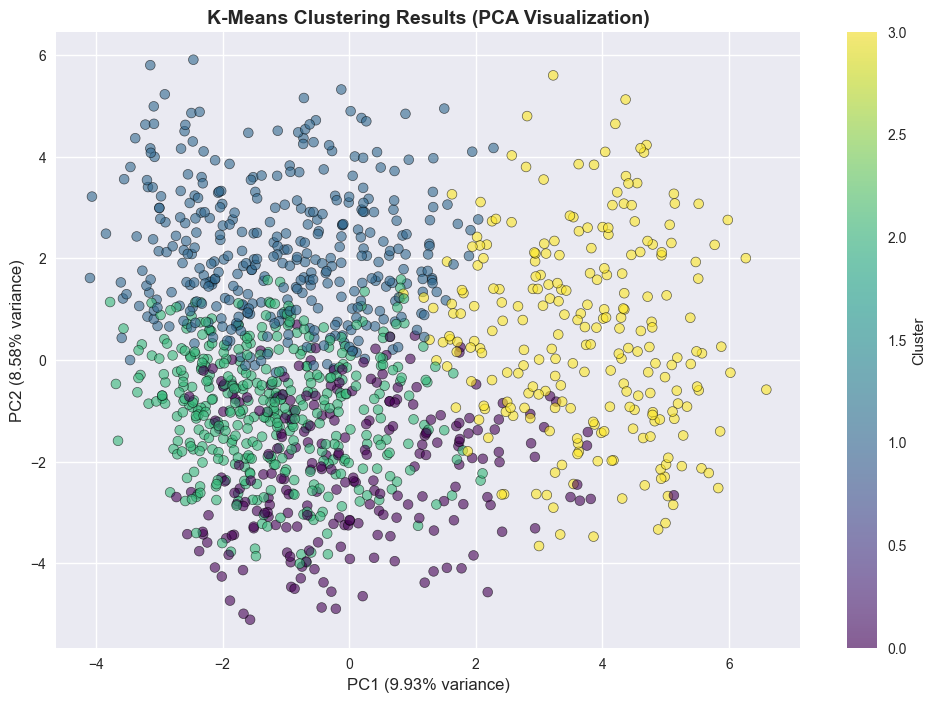


Cluster Distribution:
  Cluster 0: 234 employees (18.6%)
  Cluster 1: 368 employees (29.3%)
  Cluster 2: 413 employees (32.9%)
  Cluster 3: 242 employees (19.3%)


2. K-MODES CLUSTERING

Evaluating optimal number of clusters...


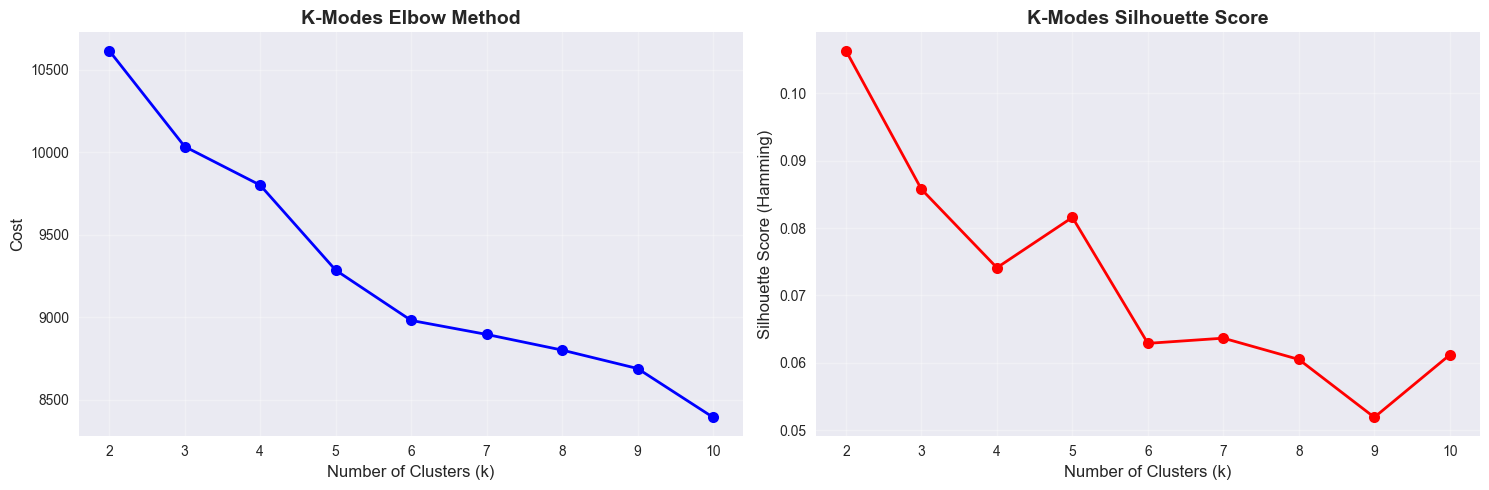


FINAL K-MODES MODEL: 4 Clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 346, cost: 9844.0
Run 1, iteration: 2/100, moves: 27, cost: 9844.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 382, cost: 10039.0
Run 2, iteration: 2/100, moves: 116, cost: 10000.0
Run 2, iteration: 3/100, moves: 4, cost: 10000.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 281, cost: 9801.0
Run 3, iteration: 2/100, moves: 65, cost: 9801.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 343, cost: 9926.0
Run 4, iteration: 2/100, moves: 40, cost: 9926.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 436, cost: 10099.0
Run 5, iteration: 2/100, moves: 47, cost: 10099.0
Init: initializing

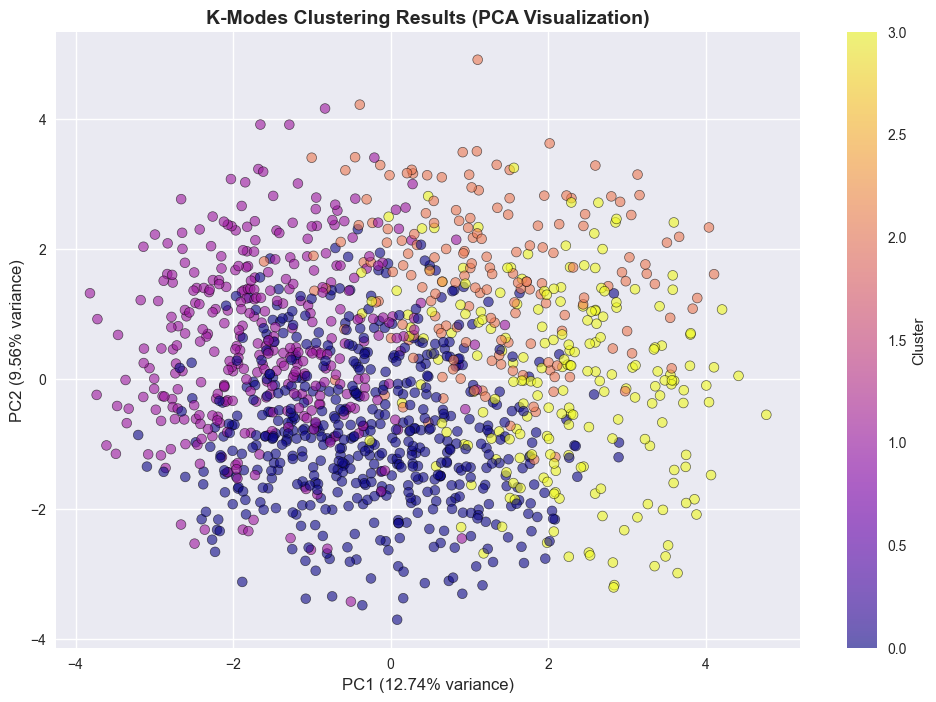


Cluster Distribution:
  Cluster 0: 532 employees (42.3%)
  Cluster 1: 345 employees (27.4%)
  Cluster 2: 171 employees (13.6%)
  Cluster 3: 209 employees (16.6%)


3. DETAILED CLUSTER PROFILING

K-MEANS CLUSTER CHARACTERISTICS

CLUSTER 0: 234 employees (18.6%)
  Demographics:
    • Average Age: 31.3 years
    • Remote Work: 40.2%
    • Tech Company: 91.5%

  Mental Health Status:
    • Treatment Rate: 55.1%
    • Family History: 44.0%
    • Work Interference: 52.6%
    • Risk Score: 2.52/6

  Company Support:
    • Benefits: 26.9%
    • Wellness Program: 8.5%
    • Help Resources: 11.1%
    • Support Score: 0.91/4

CLUSTER 1: 368 employees (29.3%)
  Demographics:
    • Average Age: 31.7 years
    • Remote Work: 31.0%
    • Tech Company: 81.5%

  Mental Health Status:
    • Treatment Rate: 83.7%
    • Family History: 58.7%
    • Work Interference: 80.7%
    • Risk Score: 4.18/6

  Company Support:
    • Benefits: 34.5%
    • Wellness Program: 2.7%
    • Help Resources: 3.5%
    • Suppo

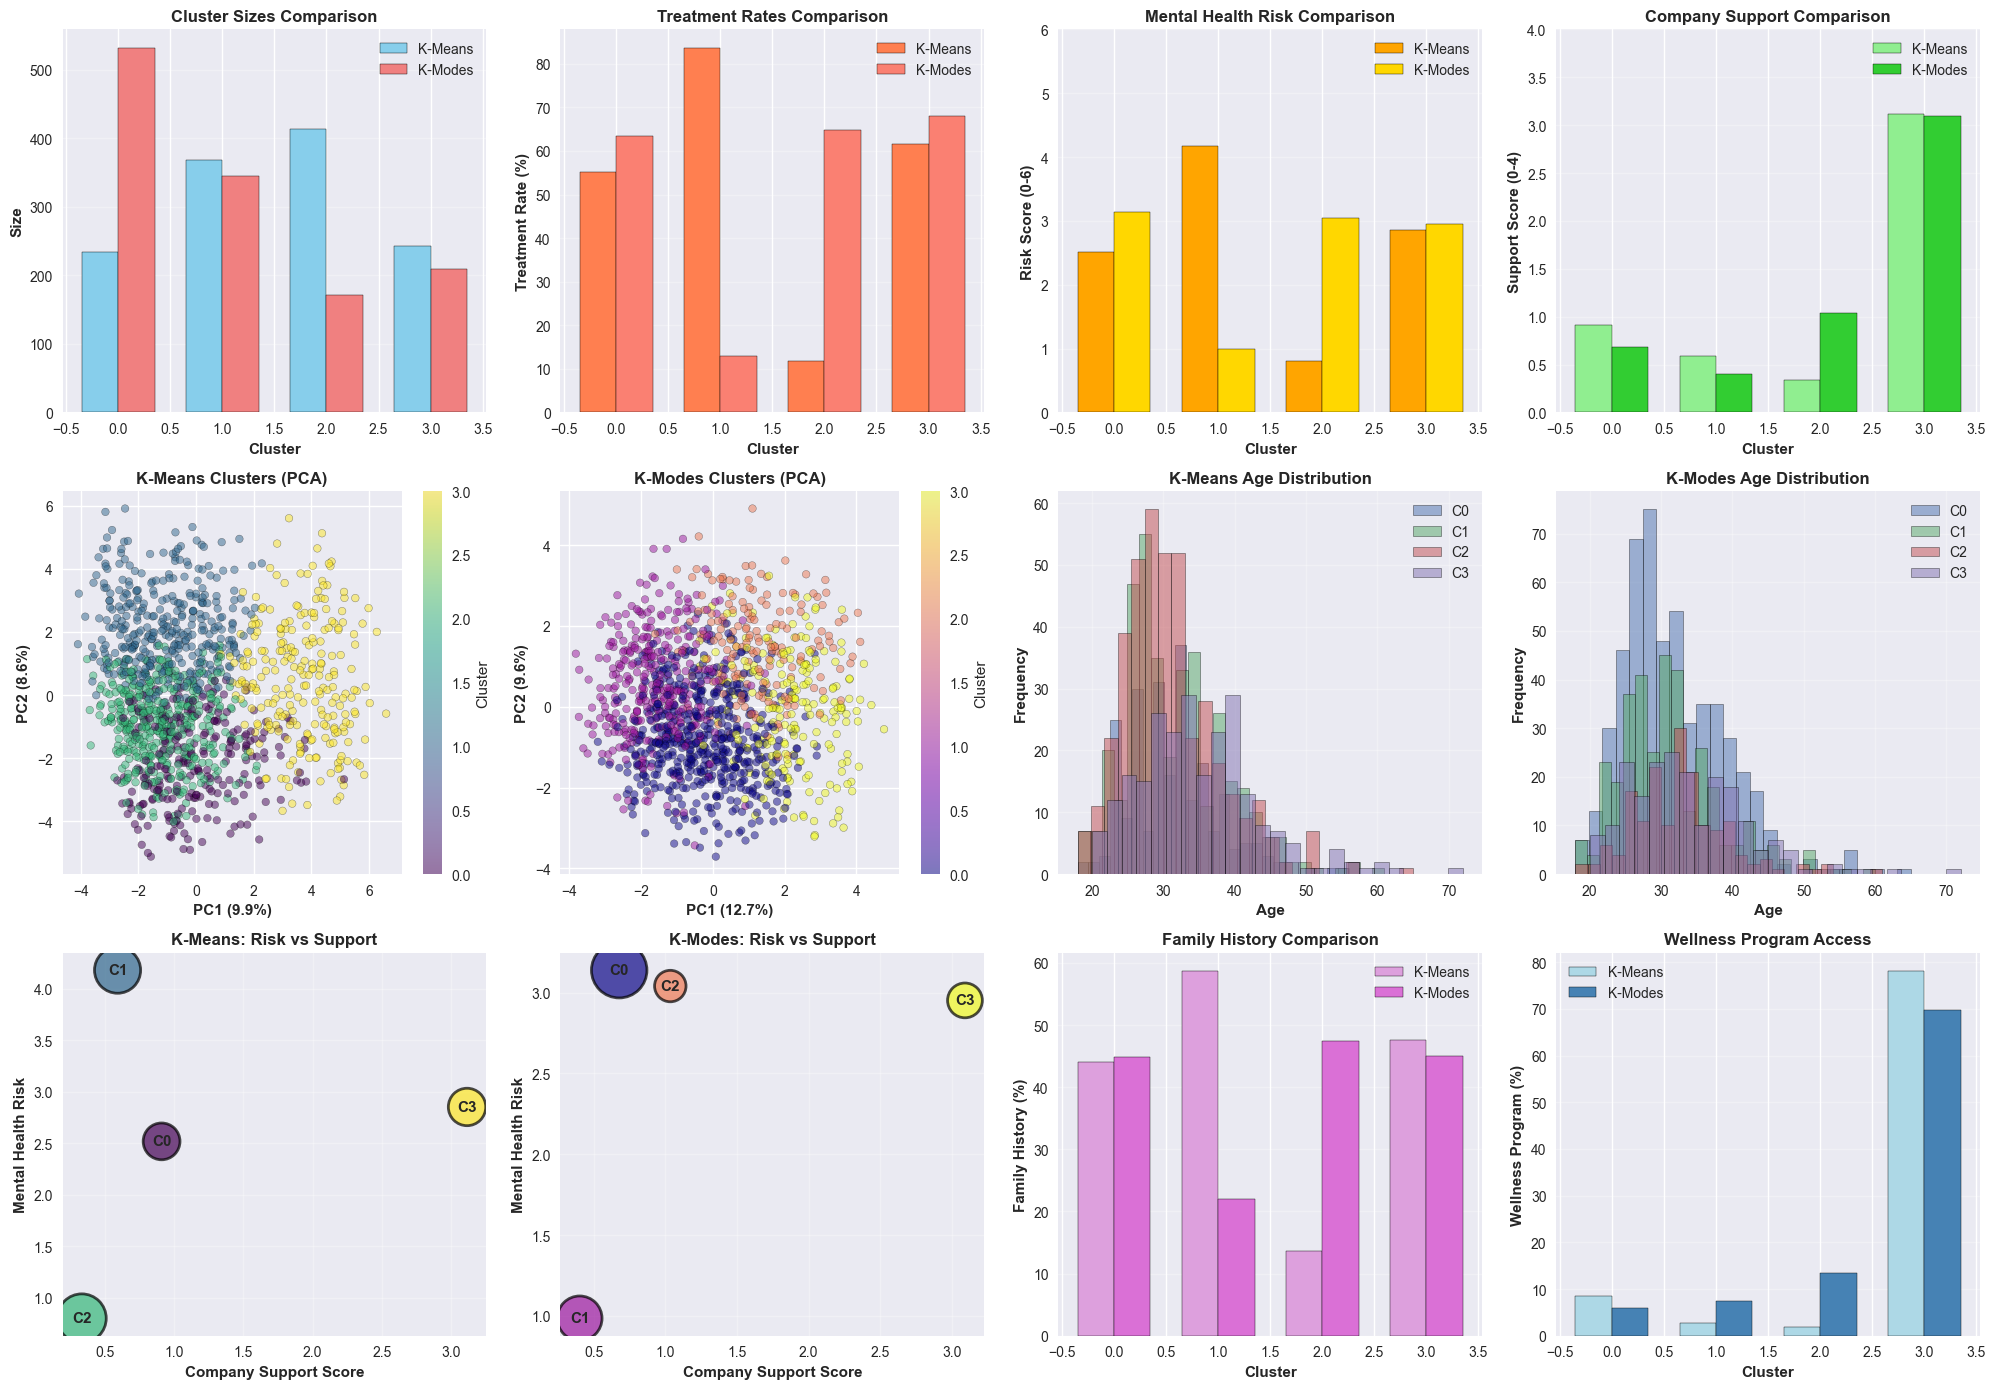



ALGORITHM COMPARISON

Silhouette Score (range: -1 to 1, higher is better):
  K-Means:  0.0550
  K-Modes:  0.0904

Note: Silhouette scores are computed with different metrics:
  - K-Means uses Euclidean distance on standardized features
  - K-Modes uses Hamming distance on categorical features
  - Direct comparison should be interpreted with caution


STATISTICAL SIGNIFICANCE TESTS

Chi-square tests evaluate if clusters differ significantly on key features:

TREATMENT:
  K-Means:  Chi² =  422.72, p-value = 0.0000  ✓ SIGNIFICANT
  K-Modes:  Chi² =  268.40, p-value = 0.0000  ✓ SIGNIFICANT

FAMILY_HISTORY:
  K-Means:  Chi² =  182.26, p-value = 0.0000  ✓ SIGNIFICANT
  K-Modes:  Chi² =   57.80, p-value = 0.0000  ✓ SIGNIFICANT

BENEFITS:
  K-Means:  Chi² =  438.52, p-value = 0.0000  ✓ SIGNIFICANT
  K-Modes:  Chi² =  624.34, p-value = 0.0000  ✓ SIGNIFICANT

WELLNESS_PROGRAM:
  K-Means:  Chi² =  777.06, p-value = 0.0000  ✓ SIGNIFICANT
  K-Modes:  Chi² =  545.03, p-value = 0.0000  ✓ SIGNIFICAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

# ============================================================================
# DATA LOADING AND CLEANING
# ============================================================================

DATA_PATH = Path("..") / ".." / ".." / "data" / "osmi-raw.csv"
df = pd.read_csv(DATA_PATH)

# Remove irrelevant columns
df = df.drop(['comments', 'state', 'Timestamp'], axis=1)

# Define feature types for filling missing values
defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

integerFeatures = ['Age']
stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 
                  'work_interfere', 'no_employees', 'remote_work', 'tech_company', 
                  'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 
                  'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 
                  'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options', 
                  'wellness_program', 'seek_help']
floatFeatures = []

# Fill missing values based on feature type
for i in df:
    if i in integerFeatures:
        df[i] = df[i].fillna(defaultInt)
    elif i in stringFeatures:
        df[i] = df[i].fillna(defaultString)
    elif i in floatFeatures:
        df[i] = df[i].fillna(defaultFloat)

# Age data cleaning: handle outliers and missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
median_age = df['Age'].median()
df.loc[df['Age'] < 18, 'Age'] = median_age
df.loc[df['Age'] > 110, 'Age'] = median_age
df['age_range'] = pd.cut(df['Age'], [0, 20, 35, 65, 100], 
                         labels=["0-20", "21-35", "36-65", "66-100"], 
                         include_lowest=True)

# Gender data cleaning: standardize gender categories
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ", 
            "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]
other_gender_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary",
                    "nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender", 
                    "male leaning androgynous", "guy (-ish) ^*^", "trans woman", "neuter", 
                    "female (trans)", "queer", "ostensibly male, unsure what that really means"]
female_str = ["female", "woman", "cis female", "f", "femake", "female ",
              "cis-female/femme", "female (cis)", "femail"]

for (row, col) in df.iterrows():
    if str.lower(col.Gender) in male_str:
        df['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)
    if str.lower(col.Gender) in female_str:
        df['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)
    if str.lower(col.Gender) in other_gender_str:
        df['Gender'].replace(to_replace=col.Gender, value='other_gender', inplace=True)

# Remove invalid gender entries
strange_list = ['A little about you', 'p']
df = df[~df['Gender'].isin(strange_list)]

# Self-employment imputation: randomly assign Yes/No to missing values
df['self_employed'] = df['self_employed'].replace('NaN', np.nan)
nan_indices = df[df['self_employed'].isna()].index.to_numpy()
np.random.seed(42)
np.random.shuffle(nan_indices)
half = len(nan_indices) // 2
df.loc[nan_indices[:half], 'self_employed'] = 'Yes'
df.loc[nan_indices[half:], 'self_employed'] = 'No'

# Work interference: replace missing with "Don't know"
df['work_interfere'] = df['work_interfere'].replace([defaultString], 'Don\'t know')

print("Dataset shape after cleaning:", df.shape)
print("\n" + "="*80)

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================
print("\nFEATURE ENGINEERING")
print("="*80)

# Mental health risk composite score (0-6)
df['mental_health_risk'] = 0
df.loc[df['treatment'] == 'Yes', 'mental_health_risk'] += 2
df.loc[df['family_history'] == 'Yes', 'mental_health_risk'] += 2
df.loc[df['work_interfere'].isin(['Often', 'Sometimes']), 'mental_health_risk'] += 1
df.loc[df['mental_health_consequence'] == 'Yes', 'mental_health_risk'] += 1

# Company support composite score (0-4)
df['company_support'] = 0
df.loc[df['benefits'] == 'Yes', 'company_support'] += 1
df.loc[df['wellness_program'] == 'Yes', 'company_support'] += 1
df.loc[df['seek_help'] == 'Yes', 'company_support'] += 1
df.loc[df['anonymity'] == 'Yes', 'company_support'] += 1

print(f"✓ Created mental_health_risk score (0-6): mean={df['mental_health_risk'].mean():.2f}")
print(f"✓ Created company_support score (0-4): mean={df['company_support'].mean():.2f}")

# Preserve original data before encoding for interpretation
df_original = df.copy()

# ============================================================================
# LABEL ENCODING
# ============================================================================
from sklearn import preprocessing

labelDict = {}
for feature in df:
    le = preprocessing.LabelEncoder()
    le.fit(df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df[feature] = le.transform(df[feature])
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] = labelValue

# Remove Country feature (high cardinality)
df = df.drop(['Country'], axis=1)
df_original = df_original.drop(['Country'], axis=1)

print(f"\n✓ Label encoding complete")
print(f"Dataset shape after encoding: {df.shape}")

# ============================================================================
# DATA PREPARATION
# ============================================================================
X = df.copy()

# Identify feature types
numerical_features = ['Age', 'mental_health_risk', 'company_support']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# ============================================================================
# K-MEANS CLUSTERING
# ============================================================================
print("\n\n" + "="*80)
print("1. K-MEANS CLUSTERING")
print("="*80)

# One-Hot Encoding: converts categorical variables to binary columns
# This is more appropriate for K-Means than label encoding as it doesn't
# impose ordinal relationships between categories
df_for_kmeans = df_original.copy()
categorical_cols = [col for col in df_for_kmeans.columns 
                   if col not in ['Age', 'mental_health_risk', 'company_support']]
df_encoded = pd.get_dummies(df_for_kmeans, columns=categorical_cols, drop_first=True)

print(f"After One-Hot Encoding: {df_encoded.shape[1]} features")

# Standardization: scales features to mean=0, std=1 for equal contribution
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# Elbow method: find optimal number of clusters
print("\nEvaluating optimal number of clusters...")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualization of clustering evaluation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('K-Means Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('K-Means Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Final K-Means model with optimal k
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"\n{'='*60}")
print(f"FINAL K-MEANS MODEL: {optimal_k} Clusters")
print(f"{'='*60}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

# PCA visualization: reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                     cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('K-Means Clustering Results (PCA Visualization)', fontsize=14, fontweight='bold')
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster size distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmeans_labels)*100:.1f}%)")

# ============================================================================
# K-MODES CLUSTERING
# ============================================================================
print("\n\n" + "="*80)
print("2. K-MODES CLUSTERING")
print("="*80)

# K-Modes uses matching dissimilarity for categorical data
X_categorical = df[categorical_features].copy()

# Elbow method for K-Modes
print("\nEvaluating optimal number of clusters...")
cost = []
silhouette_kmodes = []
K_range_modes = range(2, 11)

for k in K_range_modes:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    labels = kmode.fit_predict(X_categorical)
    cost.append(kmode.cost_)
    # Hamming distance: appropriate metric for categorical data
    silhouette_kmodes.append(silhouette_score(X_categorical, labels, metric='hamming'))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range_modes, cost, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Cost', fontsize=12)
ax1.set_title('K-Modes Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range_modes, silhouette_kmodes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score (Hamming)', fontsize=12)
ax2.set_title('K-Modes Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmodes_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Final K-Modes model
optimal_k_modes = 4
print(f"\n{'='*60}")
print(f"FINAL K-MODES MODEL: {optimal_k_modes} Clusters")
print(f"{'='*60}")

kmodes_final = KModes(n_clusters=optimal_k_modes, init='Huang', n_init=10, 
                      verbose=1, random_state=42)
kmodes_labels = kmodes_final.fit_predict(X_categorical)

print(f"\nSilhouette Score: {silhouette_score(X_categorical, kmodes_labels, metric='hamming'):.4f}")
print(f"Final Cost: {kmodes_final.cost_:.2f}")

# PCA visualization for K-Modes
X_cat_scaled = scaler.fit_transform(X_categorical)
pca_cat = PCA(n_components=2)
X_cat_pca = pca_cat.fit_transform(X_cat_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_cat_pca[:, 0], X_cat_pca[:, 1], c=kmodes_labels, 
                     cmap='plasma', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_cat.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_cat.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('K-Modes Clustering Results (PCA Visualization)', fontsize=14, fontweight='bold')
plt.savefig('kmodes_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster size distribution
unique, counts = np.unique(kmodes_labels, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} employees ({count/len(kmodes_labels)*100:.1f}%)")

# ============================================================================
# CLUSTER PROFILING
# ============================================================================
print("\n\n" + "="*80)
print("3. DETAILED CLUSTER PROFILING")
print("="*80)

# Add cluster labels to original dataframe
df_original['KMeans_Cluster'] = kmeans_labels
df_original['KModes_Cluster'] = kmodes_labels

# ============================================================================
# K-MEANS CLUSTER CHARACTERISTICS
# ============================================================================
print("\n" + "="*80)
print("K-MEANS CLUSTER CHARACTERISTICS")
print("="*80)

kmeans_profiles = []

for cluster in range(optimal_k):
    cluster_data = df_original[df_original['KMeans_Cluster'] == cluster]
    n = len(cluster_data)
    
    profile = {
        'cluster': cluster,
        'size': n,
        'pct': n / len(df_original) * 100,
        'avg_age': cluster_data['Age'].mean(),
        'treatment_rate': (cluster_data['treatment'] == 'Yes').sum() / n * 100,
        'family_history': (cluster_data['family_history'] == 'Yes').sum() / n * 100,
        'remote_work': (cluster_data['remote_work'] == 'Yes').sum() / n * 100,
        'tech_company': (cluster_data['tech_company'] == 'Yes').sum() / n * 100,
        'benefits': (cluster_data['benefits'] == 'Yes').sum() / n * 100,
        'wellness_program': (cluster_data['wellness_program'] == 'Yes').sum() / n * 100,
        'seek_help': (cluster_data['seek_help'] == 'Yes').sum() / n * 100,
        'mental_health_risk': cluster_data['mental_health_risk'].mean(),
        'company_support': cluster_data['company_support'].mean(),
        'work_interfere': (cluster_data['work_interfere'].isin(['Often', 'Sometimes'])).sum() / n * 100,
    }
    
    kmeans_profiles.append(profile)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {n} employees ({profile['pct']:.1f}%)")
    print(f"{'='*60}")
    print(f"  Demographics:")
    print(f"    • Average Age: {profile['avg_age']:.1f} years")
    print(f"    • Remote Work: {profile['remote_work']:.1f}%")
    print(f"    • Tech Company: {profile['tech_company']:.1f}%")
    print(f"\n  Mental Health Status:")
    print(f"    • Treatment Rate: {profile['treatment_rate']:.1f}%")
    print(f"    • Family History: {profile['family_history']:.1f}%")
    print(f"    • Work Interference: {profile['work_interfere']:.1f}%")
    print(f"    • Risk Score: {profile['mental_health_risk']:.2f}/6")
    print(f"\n  Company Support:")
    print(f"    • Benefits: {profile['benefits']:.1f}%")
    print(f"    • Wellness Program: {profile['wellness_program']:.1f}%")
    print(f"    • Help Resources: {profile['seek_help']:.1f}%")
    print(f"    • Support Score: {profile['company_support']:.2f}/4")

# ============================================================================
# K-MODES CLUSTER CHARACTERISTICS
# ============================================================================
print("\n\n" + "="*80)
print("K-MODES CLUSTER CHARACTERISTICS")
print("="*80)

kmodes_profiles = []

for cluster in range(optimal_k_modes):
    cluster_data = df_original[df_original['KModes_Cluster'] == cluster]
    n = len(cluster_data)
    
    profile = {
        'cluster': cluster,
        'size': n,
        'pct': n / len(df_original) * 100,
        'avg_age': cluster_data['Age'].mean(),
        'treatment_rate': (cluster_data['treatment'] == 'Yes').sum() / n * 100,
        'family_history': (cluster_data['family_history'] == 'Yes').sum() / n * 100,
        'remote_work': (cluster_data['remote_work'] == 'Yes').sum() / n * 100,
        'tech_company': (cluster_data['tech_company'] == 'Yes').sum() / n * 100,
        'benefits': (cluster_data['benefits'] == 'Yes').sum() / n * 100,
        'wellness_program': (cluster_data['wellness_program'] == 'Yes').sum() / n * 100,
        'seek_help': (cluster_data['seek_help'] == 'Yes').sum() / n * 100,
        'mental_health_risk': cluster_data['mental_health_risk'].mean(),
        'company_support': cluster_data['company_support'].mean(),
        'work_interfere': (cluster_data['work_interfere'].isin(['Often', 'Sometimes'])).sum() / n * 100,
    }
    
    kmodes_profiles.append(profile)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {n} employees ({profile['pct']:.1f}%)")
    print(f"{'='*60}")
    print(f"  Demographics:")
    print(f"    • Average Age: {profile['avg_age']:.1f} years")
    print(f"    • Remote Work: {profile['remote_work']:.1f}%")
    print(f"    • Tech Company: {profile['tech_company']:.1f}%")
    print(f"\n  Mental Health Status:")
    print(f"    • Treatment Rate: {profile['treatment_rate']:.1f}%")
    print(f"    • Family History: {profile['family_history']:.1f}%")
    print(f"    • Work Interference: {profile['work_interfere']:.1f}%")
    print(f"    • Risk Score: {profile['mental_health_risk']:.2f}/6")
    print(f"\n  Company Support:")
    print(f"    • Benefits: {profile['benefits']:.1f}%")
    print(f"    • Wellness Program: {profile['wellness_program']:.1f}%")
    print(f"    • Help Resources: {profile['seek_help']:.1f}%")
    print(f"    • Support Score: {profile['company_support']:.2f}/4")

# ============================================================================
# CLUSTER INTERPRETATION
# ============================================================================

def name_cluster(profile):
    """
    Generate cluster name based on key characteristics
    """
    risk = profile['mental_health_risk']
    support = profile['company_support']
    treatment = profile['treatment_rate']
    family = profile['family_history']
    
    # High risk clusters
    if risk >= 3.5 and support < 1.5:
        return "Critical: High Risk + Low Support"
    elif risk >= 3.5 and support >= 2.0:
        return "Managed: High Risk + Good Support"
    
    # Moderate risk clusters
    elif 2.0 <= risk < 3.5 and support >= 2.0:
        return "Moderate Risk + Supported"
    elif 2.0 <= risk < 3.5 and support < 1.5:
        return "Moderate Risk + Limited Support"
    
    # Low risk clusters
    elif risk < 1.5 and treatment < 30:
        if support < 1.0:
            return "Low Risk + Minimal Support"
        else:
            return "Healthy + Supported"
    
    # Special patterns
    elif treatment < 20 and family < 20:
        return "Low Engagement Group"
    elif treatment > 60 and family > 60:
        return "High Genetic Predisposition"
    
    # Default categorization
    else:
        risk_level = "High" if risk >= 3 else "Medium" if risk >= 2 else "Low"
        support_level = "Good" if support >= 2 else "Poor"
        return f"{risk_level} Risk + {support_level} Support"

print("\n\n" + "="*80)
print("CLUSTER INTERPRETATION")
print("="*80)

print("\n--- K-MEANS CLUSTERS ---")
for profile in kmeans_profiles:
    name = name_cluster(profile)
    print(f"\nCluster {profile['cluster']}: '{name}'")
    print(f"  Size: {profile['size']} ({profile['pct']:.1f}%)")
    print(f"  Risk: {profile['mental_health_risk']:.2f}/6, Support: {profile['company_support']:.2f}/4")
    print(f"  Treatment: {profile['treatment_rate']:.1f}%, Family History: {profile['family_history']:.1f}%")

print("\n--- K-MODES CLUSTERS ---")
for profile in kmodes_profiles:
    name = name_cluster(profile)
    print(f"\nCluster {profile['cluster']}: '{name}'")
    print(f"  Size: {profile['size']} ({profile['pct']:.1f}%)")
    print(f"  Risk: {profile['mental_health_risk']:.2f}/6, Support: {profile['company_support']:.2f}/4")
    print(f"  Treatment: {profile['treatment_rate']:.1f}%, Family History: {profile['family_history']:.1f}%")

# ============================================================================
# COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 14))

# Cluster sizes comparison
ax1 = plt.subplot(3, 4, 1)
x = np.arange(optimal_k)
width = 0.35
ax1.bar(x - width/2, [p['size'] for p in kmeans_profiles], width, label='K-Means', color='skyblue', edgecolor='black')
ax1.bar(x + width/2, [p['size'] for p in kmodes_profiles], width, label='K-Modes', color='lightcoral', edgecolor='black')
ax1.set_xlabel('Cluster', fontweight='bold')
ax1.set_ylabel('Size', fontweight='bold')
ax1.set_title('Cluster Sizes Comparison', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Treatment rates comparison
ax2 = plt.subplot(3, 4, 2)
ax2.bar(x - width/2, [p['treatment_rate'] for p in kmeans_profiles], width, label='K-Means', color='coral', edgecolor='black')
ax2.bar(x + width/2, [p['treatment_rate'] for p in kmodes_profiles], width, label='K-Modes', color='salmon', edgecolor='black')
ax2.set_xlabel('Cluster', fontweight='bold')
ax2.set_ylabel('Treatment Rate (%)', fontweight='bold')
ax2.set_title('Treatment Rates Comparison', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Risk scores comparison
ax3 = plt.subplot(3, 4, 3)
ax3.bar(x - width/2, [p['mental_health_risk'] for p in kmeans_profiles], width, label='K-Means', color='orange', edgecolor='black')
ax3.bar(x + width/2, [p['mental_health_risk'] for p in kmodes_profiles], width, label='K-Modes', color='gold', edgecolor='black')
ax3.set_xlabel('Cluster', fontweight='bold')
ax3.set_ylabel('Risk Score (0-6)', fontweight='bold')
ax3.set_title('Mental Health Risk Comparison', fontweight='bold')
ax3.legend()
ax3.set_ylim(0, 6)
ax3.grid(axis='y', alpha=0.3)

# Support scores comparison
ax4 = plt.subplot(3, 4, 4)
ax4.bar(x - width/2, [p['company_support'] for p in kmeans_profiles], width, label='K-Means', color='lightgreen', edgecolor='black')
ax4.bar(x + width/2, [p['company_support'] for p in kmodes_profiles], width, label='K-Modes', color='limegreen', edgecolor='black')
ax4.set_xlabel('Cluster', fontweight='bold')
ax4.set_ylabel('Support Score (0-4)', fontweight='bold')
ax4.set_title('Company Support Comparison', fontweight='bold')
ax4.legend()
ax4.set_ylim(0, 4)
ax4.grid(axis='y', alpha=0.3)

# K-Means PCA visualization
ax5 = plt.subplot(3, 4, 5)
scatter = ax5.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, edgecolors='k', linewidth=0.3, s=30)
ax5.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax5.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax5.set_title('K-Means Clusters (PCA)', fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Cluster')

# K-Modes PCA visualization
ax6 = plt.subplot(3, 4, 6)
scatter = ax6.scatter(X_cat_pca[:, 0], X_cat_pca[:, 1], c=kmodes_labels, cmap='plasma', alpha=0.5, edgecolors='k', linewidth=0.3, s=30)
ax6.set_xlabel(f'PC1 ({pca_cat.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax6.set_ylabel(f'PC2 ({pca_cat.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax6.set_title('K-Modes Clusters (PCA)', fontweight='bold')
plt.colorbar(scatter, ax=ax6, label='Cluster')

# Age distribution - K-Means
ax7 = plt.subplot(3, 4, 7)
for cluster in range(optimal_k):
    cluster_ages = df_original[df_original['KMeans_Cluster'] == cluster]['Age']
    ax7.hist(cluster_ages, alpha=0.5, label=f'C{cluster}', bins=25, edgecolor='black', linewidth=0.5)
ax7.set_xlabel('Age', fontweight='bold')
ax7.set_ylabel('Frequency', fontweight='bold')
ax7.set_title('K-Means Age Distribution', fontweight='bold')
ax7.legend()
ax7.grid(alpha=0.3)

# Age distribution - K-Modes
ax8 = plt.subplot(3, 4, 8)
for cluster in range(optimal_k_modes):
    cluster_ages = df_original[df_original['KModes_Cluster'] == cluster]['Age']
    ax8.hist(cluster_ages, alpha=0.5, label=f'C{cluster}', bins=25, edgecolor='black', linewidth=0.5)
ax8.set_xlabel('Age', fontweight='bold')
ax8.set_ylabel('Frequency', fontweight='bold')
ax8.set_title('K-Modes Age Distribution', fontweight='bold')
ax8.legend()
ax8.grid(alpha=0.3)

# Risk vs Support scatter - K-Means
ax9 = plt.subplot(3, 4, 9)
sizes_km = [p['size']*3 for p in kmeans_profiles]
ax9.scatter([p['company_support'] for p in kmeans_profiles], 
           [p['mental_health_risk'] for p in kmeans_profiles],
           s=sizes_km, c=range(optimal_k), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, p in enumerate(kmeans_profiles):
    ax9.annotate(f'C{i}', (p['company_support'], p['mental_health_risk']), 
                fontsize=11, fontweight='bold', ha='center', va='center')
ax9.set_xlabel('Company Support Score', fontweight='bold')
ax9.set_ylabel('Mental Health Risk', fontweight='bold')
ax9.set_title('K-Means: Risk vs Support', fontweight='bold')
ax9.grid(alpha=0.3)

# Risk vs Support scatter - K-Modes
ax10 = plt.subplot(3, 4, 10)
sizes_kmo = [p['size']*3 for p in kmodes_profiles]
ax10.scatter([p['company_support'] for p in kmodes_profiles], 
            [p['mental_health_risk'] for p in kmodes_profiles],
            s=sizes_kmo, c=range(optimal_k_modes), cmap='plasma', alpha=0.7, edgecolors='black', linewidth=2)
for i, p in enumerate(kmodes_profiles):
    ax10.annotate(f'C{i}', (p['company_support'], p['mental_health_risk']), 
                 fontsize=11, fontweight='bold', ha='center', va='center')
ax10.set_xlabel('Company Support Score', fontweight='bold')
ax10.set_ylabel('Mental Health Risk', fontweight='bold')
ax10.set_title('K-Modes: Risk vs Support', fontweight='bold')
ax10.grid(alpha=0.3)

# Family history comparison
ax11 = plt.subplot(3, 4, 11)
ax11.bar(x - width/2, [p['family_history'] for p in kmeans_profiles], width, label='K-Means', color='plum', edgecolor='black')
ax11.bar(x + width/2, [p['family_history'] for p in kmodes_profiles], width, label='K-Modes', color='orchid', edgecolor='black')
ax11.set_xlabel('Cluster', fontweight='bold')
ax11.set_ylabel('Family History (%)', fontweight='bold')
ax11.set_title('Family History Comparison', fontweight='bold')
ax11.legend()
ax11.grid(axis='y', alpha=0.3)

# Wellness programs comparison
ax12 = plt.subplot(3, 4, 12)
ax12.bar(x - width/2, [p['wellness_program'] for p in kmeans_profiles], width, label='K-Means', color='lightblue', edgecolor='black')
ax12.bar(x + width/2, [p['wellness_program'] for p in kmodes_profiles], width, label='K-Modes', color='steelblue', edgecolor='black')
ax12.set_xlabel('Cluster', fontweight='bold')
ax12.set_ylabel('Wellness Program (%)', fontweight='bold')
ax12.set_title('Wellness Program Access', fontweight='bold')
ax12.legend()
ax12.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# ALGORITHM COMPARISON
# ============================================================================
print("\n\n" + "="*80)
print("ALGORITHM COMPARISON")
print("="*80)

# Silhouette scores comparison
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmodes_silhouette = silhouette_score(X_categorical, kmodes_labels, metric='hamming')

print("\nSilhouette Score (range: -1 to 1, higher is better):")
print(f"  K-Means:  {kmeans_silhouette:.4f}")
print(f"  K-Modes:  {kmodes_silhouette:.4f}")

print("\nNote: Silhouette scores are computed with different metrics:")
print("  - K-Means uses Euclidean distance on standardized features")
print("  - K-Modes uses Hamming distance on categorical features")
print("  - Direct comparison should be interpreted with caution")

# ============================================================================
# STATISTICAL SIGNIFICANCE TESTS
# ============================================================================
print("\n\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)
print("\nChi-square tests evaluate if clusters differ significantly on key features:")

# Test significance for important categorical features
significant_features_km = []
significant_features_kmo = []

for feature in ['treatment', 'family_history', 'benefits', 'wellness_program', 'remote_work']:
    print(f"\n{feature.upper()}:")
    
    # K-Means chi-square test
    contingency_km = pd.crosstab(df_original['KMeans_Cluster'], df_original[feature])
    chi2_km, p_km, _, _ = chi2_contingency(contingency_km)
    sig_km = "✓ SIGNIFICANT" if p_km < 0.05 else "✗ Not significant"
    print(f"  K-Means:  Chi² = {chi2_km:7.2f}, p-value = {p_km:.4f}  {sig_km}")
    if p_km < 0.05:
        significant_features_km.append(feature)
    
    # K-Modes chi-square test
    contingency_kmo = pd.crosstab(df_original['KModes_Cluster'], df_original[feature])
    chi2_kmo, p_kmo, _, _ = chi2_contingency(contingency_kmo)
    sig_kmo = "✓ SIGNIFICANT" if p_kmo < 0.05 else "✗ Not significant"
    print(f"  K-Modes:  Chi² = {chi2_kmo:7.2f}, p-value = {p_kmo:.4f}  {sig_kmo}")
    if p_kmo < 0.05:
        significant_features_kmo.append(feature)

print(f"\n\nSummary:")
print(f"  K-Means:  {len(significant_features_km)}/5 features show significant cluster differences")
print(f"  K-Modes:  {len(significant_features_kmo)}/5 features show significant cluster differences")

# ============================================================================
# KEY FINDINGS
# ============================================================================
print("\n\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# High-risk clusters identification
high_risk_km = [i for i, p in enumerate(kmeans_profiles) if p['mental_health_risk'] > 3]
high_risk_kmo = [i for i, p in enumerate(kmodes_profiles) if p['mental_health_risk'] > 3]

print("\n1. HIGH-RISK CLUSTERS:")
print(f"   K-Means identified {len(high_risk_km)} high-risk cluster(s): {high_risk_km}")
if high_risk_km:
    for c in high_risk_km:
        print(f"     - Cluster {c}: {kmeans_profiles[c]['size']} employees, risk={kmeans_profiles[c]['mental_health_risk']:.2f}")

print(f"\n   K-Modes identified {len(high_risk_kmo)} high-risk cluster(s): {high_risk_kmo}")
if high_risk_kmo:
    for c in high_risk_kmo:
        print(f"     - Cluster {c}: {kmodes_profiles[c]['size']} employees, risk={kmodes_profiles[c]['mental_health_risk']:.2f}")

# Low support clusters identification
low_support_km = [i for i, p in enumerate(kmeans_profiles) if p['company_support'] < 1.5]
low_support_kmo = [i for i, p in enumerate(kmodes_profiles) if p['company_support'] < 1.5]

print("\n2. LOW COMPANY SUPPORT CLUSTERS:")
print(f"   K-Means: {len(low_support_km)} cluster(s) with inadequate support: {low_support_km}")
if low_support_km:
    for c in low_support_km:
        print(f"     - Cluster {c}: {kmeans_profiles[c]['size']} employees, support={kmeans_profiles[c]['company_support']:.2f}")

print(f"\n   K-Modes: {len(low_support_kmo)} cluster(s) with inadequate support: {low_support_kmo}")
if low_support_kmo:
    for c in low_support_kmo:
        print(f"     - Cluster {c}: {kmodes_profiles[c]['size']} employees, support={kmodes_profiles[c]['company_support']:.2f}")

# Critical clusters (high risk + low support)
print("\n3. CRITICAL CLUSTERS (High Risk + Low Support):")
critical_km = [i for i, p in enumerate(kmeans_profiles) 
               if p['mental_health_risk'] > 3 and p['company_support'] < 1.5]
critical_kmo = [i for i, p in enumerate(kmodes_profiles) 
                if p['mental_health_risk'] > 3 and p['company_support'] < 1.5]

if critical_km:
    print(f"   K-Means: Cluster(s) {critical_km} require immediate intervention")
    for c in critical_km:
        print(f"     - {kmeans_profiles[c]['size']} employees at critical risk")
else:
    print("   K-Means: No critical clusters identified")

if critical_kmo:
    print(f"   K-Modes: Cluster(s) {critical_kmo} require immediate intervention")
    for c in critical_kmo:
        print(f"     - {kmodes_profiles[c]['size']} employees at critical risk")
else:
    print("   K-Modes: No critical clusters identified")

# Algorithm recommendation
print("\n4. ALGORITHM RECOMMENDATION:")
print("\n   K-Means:")
print("     ✓ Effective after One-Hot Encoding transformation")
print("     ✓ Computationally efficient for large datasets")
print("     ✓ Well-suited for mixed numerical-categorical data")
print("     ✗ Assumes spherical cluster shapes")

print("\n   K-Modes:")
print("     ✓ Purpose-built for categorical data")
print("     ✓ Uses appropriate distance metric (Hamming/matching)")
print("     ✓ Preserves categorical variable structure")
print("     ✗ Limited applicability to numerical features")

if kmodes_silhouette > kmeans_silhouette:
    print(f"\n   → For this dataset, K-Modes shows better cluster separation")
    print(f"     (Silhouette: {kmodes_silhouette:.4f} vs {kmeans_silhouette:.4f})")
else:
    print(f"\n   → For this dataset, K-Means shows better cluster separation")
    print(f"     (Silhouette: {kmeans_silhouette:.4f} vs {kmodes_silhouette:.4f})")

print("\n   Recommendation: Given the predominantly categorical nature of")
print("   mental health survey data, both algorithms provide valuable insights.")
print("   K-Modes offers more interpretable results for categorical patterns,")
print("   while K-Means with One-Hot Encoding provides robust statistical metrics.")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nGenerated files:")
print("  • kmeans_evaluation.png - Elbow and silhouette curves for K-Means")
print("  • kmeans_clusters.png - PCA visualization of K-Means clusters")
print("  • kmodes_evaluation.png - Elbow and silhouette curves for K-Modes")
print("  • kmodes_clusters.png - PCA visualization of K-Modes clusters")
print("  • comprehensive_clustering_comparison.png - Side-by-side algorithm comparison")
print("="*80)